In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
dataset = pd.read_csv(r"C:\Users\91958\Desktop\Machine Learning\datasets\Position_Salaries.csv")
dataset.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 368.0+ bytes


In [4]:
dataset.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [5]:
dataset.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [6]:
print("Rows :", dataset.shape[0])
print("Columns :", dataset.shape[1])

Rows : 10
Columns : 3


In [7]:
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values

In [8]:
print("Features")
print(X)
print("Target Varible")
print(y)

Features
[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
Target Varible
[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [9]:
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X)

In [10]:
print(X_poly)

[[1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00]
 [1.000e+00 2.000e+00 4.000e+00 8.000e+00 1.600e+01]
 [1.000e+00 3.000e+00 9.000e+00 2.700e+01 8.100e+01]
 [1.000e+00 4.000e+00 1.600e+01 6.400e+01 2.560e+02]
 [1.000e+00 5.000e+00 2.500e+01 1.250e+02 6.250e+02]
 [1.000e+00 6.000e+00 3.600e+01 2.160e+02 1.296e+03]
 [1.000e+00 7.000e+00 4.900e+01 3.430e+02 2.401e+03]
 [1.000e+00 8.000e+00 6.400e+01 5.120e+02 4.096e+03]
 [1.000e+00 9.000e+00 8.100e+01 7.290e+02 6.561e+03]
 [1.000e+00 1.000e+01 1.000e+02 1.000e+03 1.000e+04]]


In [11]:
feature_names = poly_reg.get_feature_names_out(["Level"])
print(feature_names)

['1' 'Level' 'Level^2' 'Level^3' 'Level^4']


In [12]:
model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [13]:
y_pred = model.predict(X_poly)

In [14]:
comparison = pd.DataFrame({
    "Actual": y,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,45000,53356.643357
1,50000,31759.906760
2,60000,58642.191142
3,80000,94632.867133
4,110000,121724.941725
5,150000,143275.058275
6,200000,184003.496503
7,300000,289994.172494
8,500000,528694.638695
9,1000000,988916.083916


In [15]:
mse = mean_squared_error(y, y_pred)

print("Mean Squared Error:", mse)

r2 = r2_score(y, y_pred)

print("R² Score:", r2)

Mean Squared Error: 210343822.84382358
R² Score: 0.9973922891706614


C:\Users\91958\AppData\Local\Temp\ipykernel_11116\33441059.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


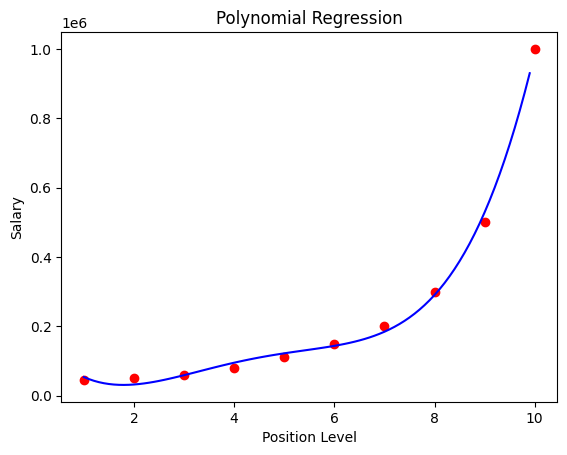

In [16]:
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))

plt.scatter(X, y, color="red")

plt.plot(
    X_grid,
    model.predict(poly_reg.transform(X_grid)),
    color="blue"
)

plt.title("Polynomial Regression")
plt.xlabel("Position Level")
plt.ylabel("Salary")

plt.show()

In [17]:
new_level = [[6.5]]

prediction = model.predict(poly_reg.transform(new_level))

print("Predicted Salary:", prediction[0])

Predicted Salary: 158862.45265150236


In [18]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")

print(model.coef_)

Intercept: 184166.66666697623

Coefficients:
[      0.         -211002.33100264   94765.44289054  -15463.2867133
     890.15151515]
